In [7]:
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)
from torch.utils.data import DataLoader


# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")




Используется устройство: cpu


In [8]:
dataset = load_dataset("emotion")

# Размеры split-частей
print("Размер train:", len(dataset["train"]))
print("Размер validation:", len(dataset["validation"]))
print("Размер test:", len(dataset["test"]))

# Отображение названий классов
label_names = dataset["train"].features["label"].names
print("Классы:", label_names)

# Несколько примеров
print("\nПримеры текстов и меток:")
for i in range(5):
    example = dataset["train"][i]
    print(f"Текст: {example['text']} -> Метка: {label_names[example['label']]}")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Выбираем несколько текстов для демонстрации
sample_texts = [
    "i am feeling very happy today",
    "this is so sad",
    "i love this movie",
    "i am angry about what happened",
    "that was a surprising turn of events"
]

for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    input_ids = tokenizer.encode(text, add_special_tokens=True)
    print(f"\nТекст: {text}")
    print(f"Токены: {tokens}")
    print(f"input_ids: {input_ids}")
    print(f"attention_mask: [1]*{len(input_ids)}")
    print("---")

# Пример padding / truncation
encoded = tokenizer(
    sample_texts,
    padding="max_length",
    truncation=True,
    max_length=16,
    return_tensors="pt"
)
print("\nФорма после padding/truncation (batch, max_length):", encoded["input_ids"].shape)

Размер train: 16000
Размер validation: 2000
Размер test: 2000
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры текстов и меток:
Текст: i didnt feel humiliated -> Метка: sadness
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake -> Метка: sadness
Текст: im grabbing a minute to post i feel greedy wrong -> Метка: anger
Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property -> Метка: love
Текст: i am feeling grouchy -> Метка: anger

Текст: i am feeling very happy today
Токены: ['i', 'am', 'feeling', 'very', 'happy', 'today']
input_ids: [101, 1045, 2572, 3110, 2200, 3407, 2651, 102]
attention_mask: [1]*8
---

Текст: this is so sad
Токены: ['this', 'is', 'so', 'sad']
input_ids: [101, 2023, 2003, 2061, 6517, 102]
attention_mask: [1]*6
---

Текст: i love this movie
Токены: ['i', 'love', 'this', 'movie']
input_ids: [101, 1045, 2293, 2023, 3185, 102]
attention_mas

In [9]:
pretrained_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_names)
).to(device)
pretrained_model.eval()

# Создадим пайплайн для инференса
classifier = pipeline(
    "text-classification",
    model=pretrained_model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# Проверяем на тех же примерах
test_examples = [
    "i feel great and excited",
    "this is terrible, i want to cry",
    "she is so cute, i adore her",
    "i hate you",
    "what a shocking news"
]

print("Результаты инференса готовой модели (без обучения):")
for text in test_examples:
    result = classifier(text)[0]
    print(f"Текст: {text}")
    print(f"Предсказанный класс: {result['label']}, уверенность: {result['score']:.3f}")
    print()



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


Результаты инференса готовой модели (без обучения):
Текст: i feel great and excited
Предсказанный класс: LABEL_3, уверенность: 0.252

Текст: this is terrible, i want to cry
Предсказанный класс: LABEL_3, уверенность: 0.264

Текст: she is so cute, i adore her
Предсказанный класс: LABEL_3, уверенность: 0.231

Текст: i hate you
Предсказанный класс: LABEL_3, уверенность: 0.192

Текст: what a shocking news
Предсказанный класс: LABEL_4, уверенность: 0.190



In [10]:
# import sys
# print(sys.executable)
# !{sys.executable} -m pip install --upgrade accelerate

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Повторно загружаем модель (свежие веса)
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_names)
).to(device)


# Токенизация всего датасета
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=64  # разумная длина для эмоций
    )


tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Убираем колонку 'text' (она не нужна модели)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Разделение уже есть: train, validation, test
train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["validation"]
test_dataset = tokenized_dataset["test"]

# Параметры обучения
training_args = TrainingArguments(
    output_dir="./artifacts",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=torch.cuda.is_available(),
)


# Метрики
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}


# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

# Оценка на validation (лучшая модель уже загружена)
val_metrics = trainer.evaluate()
print("Метрики на validation (лучшая модель):")
print(val_metrics)

# Финальная оценка на test
test_metrics = trainer.predict(test_dataset).metrics
print("Метрики на test:")
print(test_metrics)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.259700,0.214928,0.923500,0.899304
2,0.130100,0.167347,0.932000,0.903967
3,0.081400,0.159653,0.938500,0.913030


/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Метрики на validation (лучшая модель):
{'eval_loss': 0.1596526801586151, 'eval_accuracy': 0.9385, 'eval_f1_macro': 0.9130296319412686, 'eval_runtime': 7.461, 'eval_samples_per_second': 268.061, 'eval_steps_per_second': 16.754, 'epoch': 3.0}


/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Метрики на test:
{'test_loss': 0.16191840171813965, 'test_accuracy': 0.935, 'test_f1_macro': 0.8937722557443085, 'test_runtime': 7.5276, 'test_samples_per_second': 265.69, 'test_steps_per_second': 16.606}


/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test Accuracy: 0.9350
Test F1 Macro: 0.8938


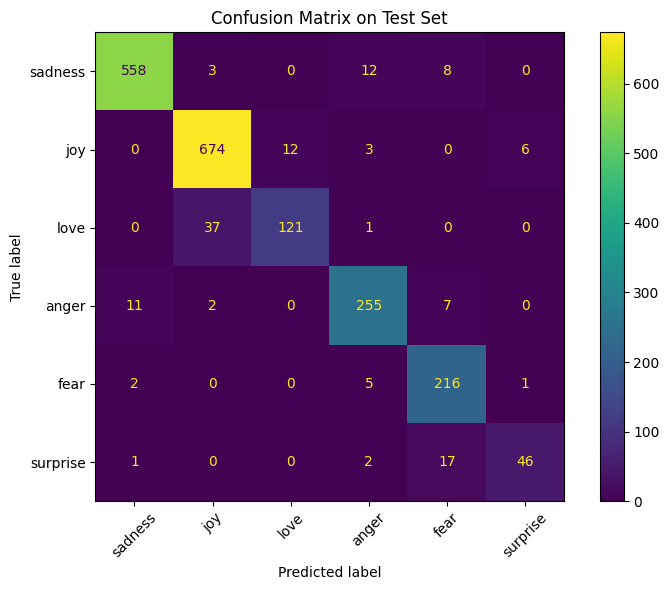

Сохранено sample_predictions.csv
                                                text true_label pred_label  \
0  i feel so dirty but after spending a day at th...    sadness    sadness   
1  i could feel his breath on me and smell the sw...        joy       love   
2                   i just want to feel loved by you       love       love   
3  i have felt the need to write out my sometimes...      anger      anger   
4         at a party i met a girl who drew me to her      anger       fear   
5             i feel this strange sort of liberation   surprise       fear   
6  i remember feeling thrilled to use my nursing ...        joy        joy   
7  i always feel sympathetic for those that do as...       love       love   
8  i feel a little stunned but can t imagine what...   surprise   surprise   
9  i feel slytherin is my house slytherin is for ...        joy        joy   

   confidence  
0      0.9996  
1      0.9082  
2      0.9980  
3      0.9721  
4      0.8340  
5      0.708

In [11]:
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=-1)

# Метрики
test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Macro: {test_f1:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()

# Примеры предсказаний (10 случайных примеров из test)
test_texts = dataset["test"]["text"]
indices = np.random.choice(len(test_texts), 10, replace=False)

sample_predictions = []
for idx in indices:
    true_label = label_names[y_true[idx]]
    pred_label = label_names[y_pred[idx]]
    # confidence (softmax от логитов)
    probs = torch.softmax(torch.tensor(logits[idx]), dim=0)
    confidence = probs[y_pred[idx]].item()
    sample_predictions.append({
        "text": test_texts[idx],
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": round(confidence, 4)
    })

df_preds = pd.DataFrame(sample_predictions)
df_preds.to_csv("artifacts/sample_predictions.csv", index=False)
print("Сохранено sample_predictions.csv")
print(df_preds)

# Покажем несколько ошибок
print("\nПримеры ошибок модели:")
errors = [(i, y_true[i], y_pred[i]) for i in range(len(y_true)) if y_true[i] != y_pred[i]]
for i, true, pred in errors[:5]:
    print(f"Текст: {test_texts[i][:200]}...")
    print(f"Истинная эмоция: {label_names[true]}, Предсказано: {label_names[pred]}")
    print()